In [21]:
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.config import BRENT_DATA

from src.preprocessing import (
    load_oil_data,
    preprocess_dates,
    compute_log_returns,
    compute_rolling_volatility
)

from src.visualizations import (
    plot_price,
    plot_log_returns,
    plot_volatility,
    plot_change_point
)

from src.statistics import adf_test
from src.bayesian_model import (
    build_change_point_model,
    sample_model,
    summarize_trace,
    plot_trace
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [3]:
oil_df = load_oil_data(BRENT_DATA)

# Preprocess

In [4]:
oil_df = preprocess_dates(oil_df)

# Plot raw prices

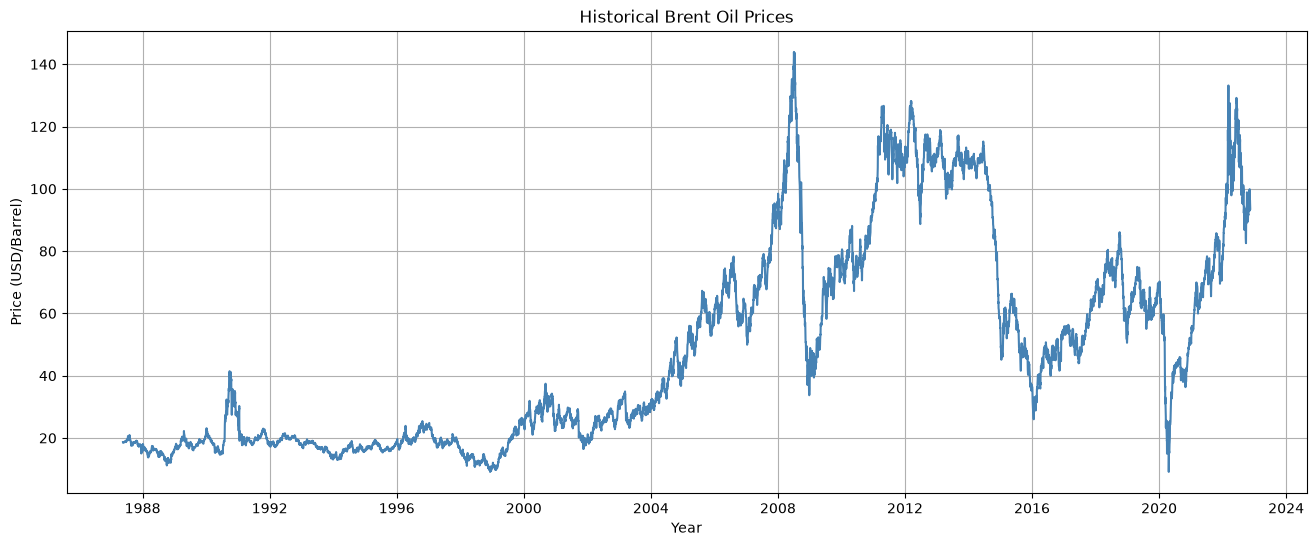

In [5]:
plot_price(oil_df)

# log returns

In [6]:
oil_df = compute_log_returns(oil_df)

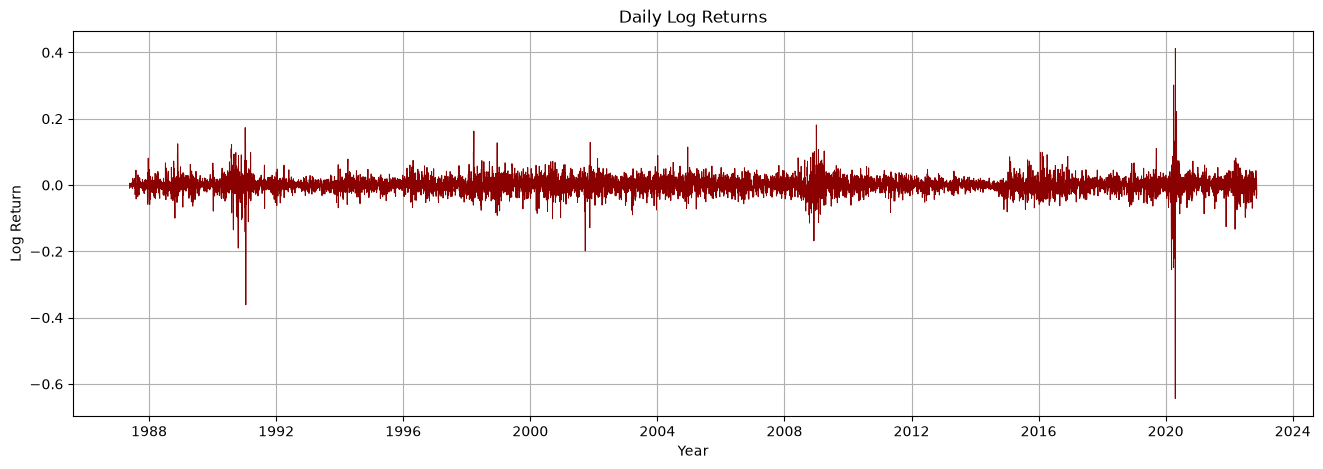

In [7]:
plot_log_returns(oil_df)

In [8]:
oil_df

,Date,Price,LogPrice,LogReturn
0,1987-05-21,18.45,2.915064,-0.009709
1,1987-05-22,18.55,2.920470,0.005405
2,1987-05-25,18.60,2.923162,0.002692
3,1987-05-26,18.63,2.924773,0.001612
4,1987-05-27,18.60,2.923162,-0.001612
...,...,...,...,...
9005,2022-11-08,96.85,4.573163,-0.030706
9006,2022-11-09,93.05,4.533137,-0.040026
9007,2022-11-10,94.25,4.545951,0.012814
9008,2022-11-11,96.37,4.568195,0.022244


# Volatility

In [9]:
oil_df = compute_rolling_volatility(oil_df)

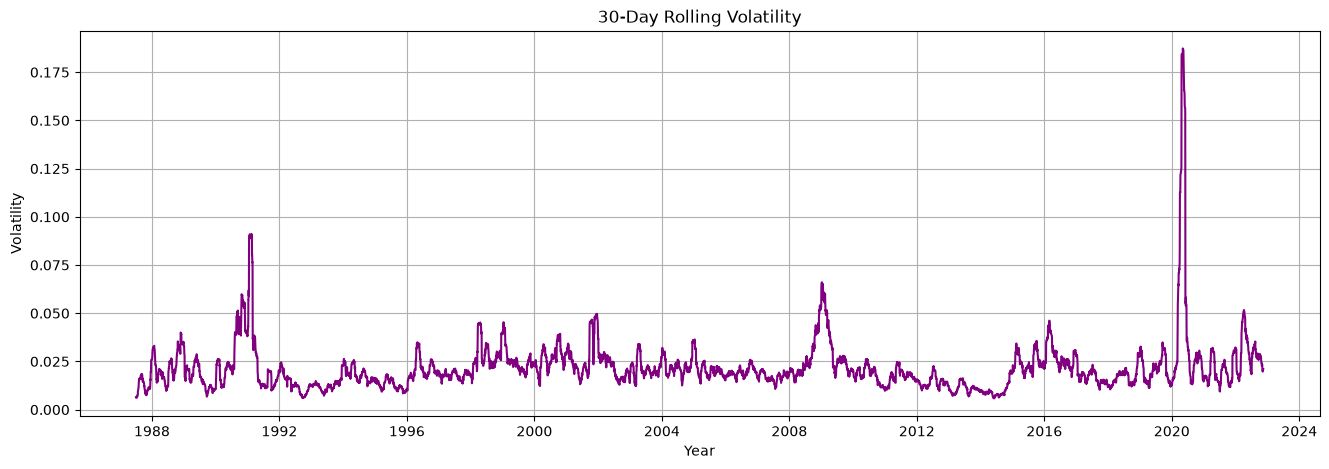

In [10]:
plot_volatility(oil_df)

In [10]:
adf_test(oil_df["LogReturn"])

Augmented Dickey-Fuller Test
ADF Statistic : -16.4271
p-value       : 0.0000

Critical Values
1%: -3.4311
5%: -2.8619
10%: -2.5669

Series is stationary.


(np.float64(-16.427113494485894),
 np.float64(2.4985801611428892e-29),
 28,
 8981,
 {'1%': np.float64(-3.4310783342658615),
  '5%': np.float64(-2.861861876398633),
  '10%': np.float64(-2.566941329781918)},
 np.float64(-40421.4169199348))

In [12]:
data = oil_df["LogReturn"].values

# Build Model

In [13]:
model = build_change_point_model(data)

# Sample

In [22]:
trace = sample_model(model)

Multiprocess sampling (4 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


c:\Users\bemnet\Desktop\10academy\week10\change-point-analysis\venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

: 

: 

In [14]:
weekly_df = (
    oil_df
    .set_index("Date")
    .resample("W")
    .mean()
    .reset_index()
)

In [15]:
data_weekly = weekly_df["LogReturn"].values

In [16]:
model_weekly = build_change_point_model(data_weekly)

In [17]:
trace_weekly = sample_model(model_weekly)

Multiprocess sampling (4 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


c:\Users\bemnet\Desktop\10academy\week10\change-point-analysis\venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

ValueError: Not enough samples to build a trace.

In [12]:
monthly_df = (
    oil_df
    .set_index("Date")
    .resample("ME")
    .mean()
    .reset_index()
)

In [18]:
print(len(monthly_df))

427


In [13]:
data_monthly = monthly_df["LogReturn"].values

In [15]:
model_monthly = build_change_point_model(data_monthly)

In [16]:
trace_monthly = sample_model(model_monthly)

Multiprocess sampling (4 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


c:\Users\bemnet\Desktop\10academy\week10\change-point-analysis\venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 41329 seconds.
There were 68 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [22]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [24]:
y = oil_df["Price"].values
n_obs = len(y)
idx = np.arange(n_obs)
y_mean = y.mean()

print(f"Observations (n): {n_obs}")
print(f"Data mean       : ${y_mean:.2f}")
import pymc as pm
with pm.Model() as change_point_model:
    # --- Priors ---
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_obs - 1)
    mu1 = pm.Normal("mu1", mu=y_mean, sigma=10)
    mu2 = pm.Normal("mu2", mu=y_mean, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    # --- Switch function ---
    mu = pm.math.switch(tau >= idx, mu1, mu2)

    # --- Likelihood ---
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y)

print("Model defined successfully.")

Observations (n): 9010
Data mean       : $48.42
Model defined successfully.


In [ ]:
with change_point_model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        cores=1,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )
print("Sampling complete.")

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


c:\Users\bemnet\Desktop\10academy\week10\change-point-analysis\venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

## Summarize Trace

In [17]:
summary = summarize_trace(trace_monthly)

summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,216.992,146.941,0.000,414.000,15.845,2.988,90.0,190.0,1.02
mu_1,-0.000,0.002,-0.002,0.001,0.000,0.000,1132.0,305.0,1.01
mu_2,0.001,0.001,-0.001,0.003,0.000,0.000,119.0,44.0,1.02
sigma,0.006,0.000,0.005,0.006,0.000,0.000,524.0,396.0,1.00


## Plot Trace

In [ ]:
plot_trace(trace)

# Estimated Change Point

In [ ]:
tau_estimate = int(
    trace.posterior["tau"]
    .mean()
    .values
)

print(tau_estimate)

In [ ]:
change_date = oil_df.iloc[tau_estimate]["Date"]

print(change_date)

In [ ]:
plot_change_point(
    oil_df,
    tau_estimate
)